<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/%E8%87%AA%E7%84%B6%E8%A8%80%E8%AA%9E%E5%87%A6%E7%90%86%E2%91%A3%E6%96%87%E7%AB%A0%E3%81%AE%E3%83%8D%E3%82%AC%E3%83%9D%E3%82%B8%E5%88%A4%E5%AE%9A_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=#0e89b2>0. ライブラリのインポート</font>

In [ ]:
! pip install janome
! pip install japanize_matplotlib
! pip install -U accelerate
! pip install -U transformers
! pip install fugashi ipadic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 28.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 34.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=ed8865f3452c376f70a25e6b525126d70370bb8e7bfe4d21635f5eb00bdb1928
  Stored in directory: /root/.cache/pip/wheels/61/7a/6b/df1f79be9c59862525070e157e62b08eab8ece27c1b68fbb94
Successfully built japanize_matplotlib
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 60.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.46.2
    Uninstalling transformers-4.46.2:
      Successfully uninstalled transformers-4.46.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 

In [ ]:
#基本ライブラリ
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

#自然言語処理用ライブラリ
from janome.tokenizer import Tokenizer
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

#その他
from google.colab import files
import codecs
import csv

%matplotlib inline

ImportError: cannot import name 'load_metric' from 'datasets' (/usr/local/lib/python3.10/dist-packages/datasets/__init__.py)

# <font color=#0e89b2>1. 文章の感情分析とは</font>

## <font color=#0e89b2>1.1 文章の感情分析の概要</font>


文章の感情判定とは、文章に込められた感情を推測する技術です。<br>
文章に含まれる単語や表現を分析することによって、<br>
ポジティブやネガティブ、怒りや悲しみ、喜びといった感情を判定することが出来ます。

## <font color=#0e89b2>1.2 文章の感情分析の手法</font>

文章の感情分析には、大きく2つの手法があります。

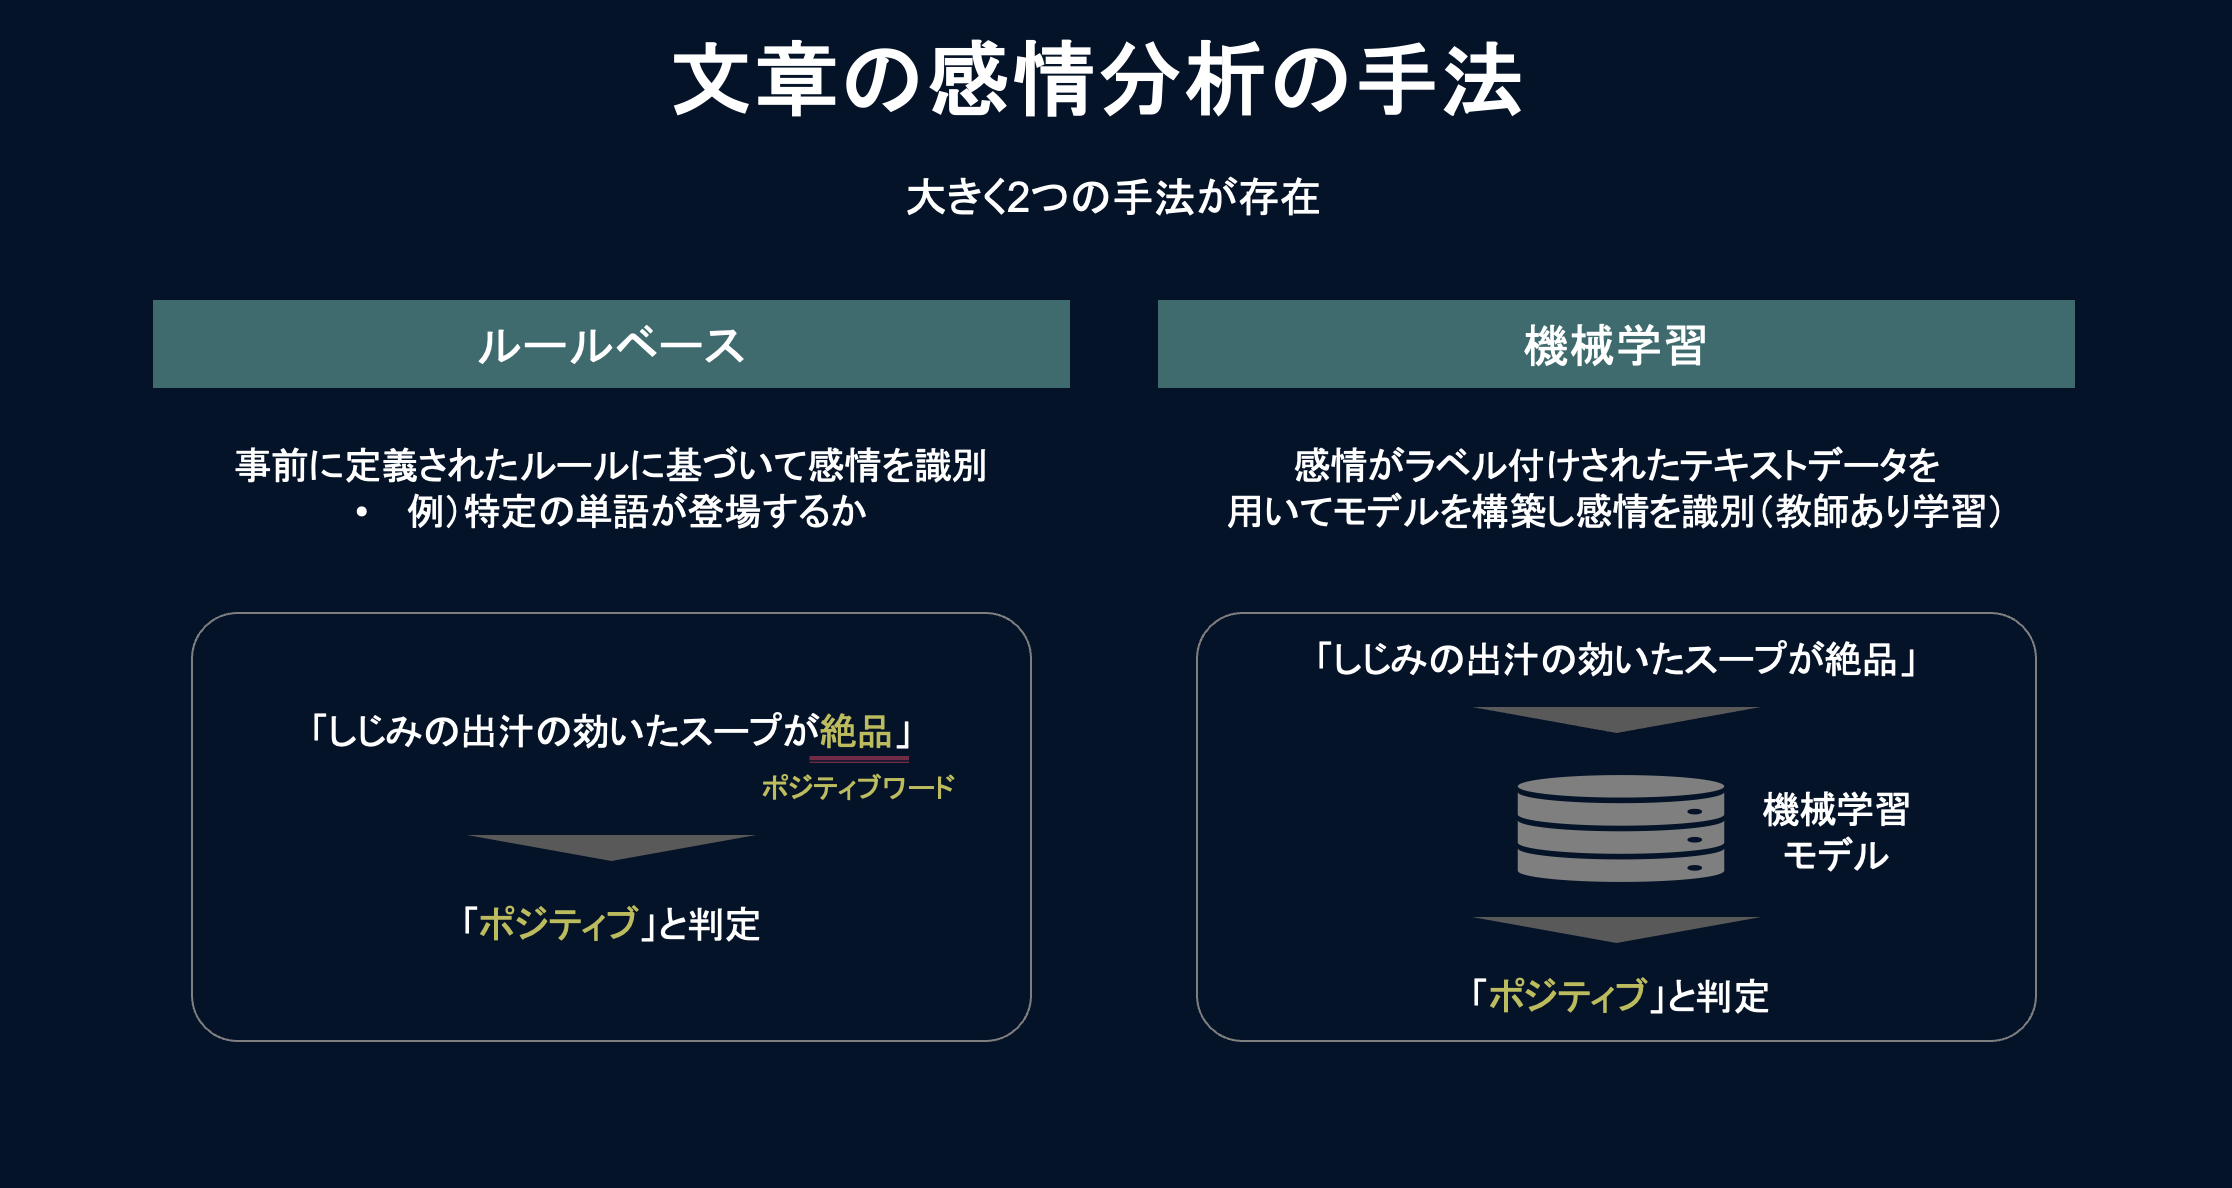

「ルールベース」と「機械学習」には、それぞれメリットとデメリットがあります。<br>

|  | ルールベース | 機械学習 |
|    ---   |    ---     |  ---  |
| メリット | 説明性の高さ	|	柔軟性の高さ	|
| デメリット |	柔軟性の不足 |	ブラックボックス問題	|

例えば単語のポジネガだけで判定する単純なルールベースの場合、<br>
「スープが絶品」という文章はポジティブと判定できますが、<br>
「スープが絶品というわけではない」という文章はポジティブと判定できません。<br>
<br>
一方機械学習モデルの場合、<br>
「スープが絶品というわけではない」という文章もネガティブと判定できる可能性が高いですが、<br>
なぜそれをネガティブと判定したかの根拠の説明は難しくなります。（ブラックボックス）<br>
<br>
この講座ではルールベースでの実装を行い、次の講座で機械学習モデルによる実装を行います。

## <font color=#0e89b2>1.3 文章の感情判定の実用例</font>

文章の感情分析の技術は、例えば下記のような場面で実用されています。
* 社員のストレスチェック（チャット文を解析）
* SNSやレビュー内容の分析
* 自動車事故の防止（例：会話内容から怒りの感情を検知し煽り運転を抑制）

# <font color=#0e89b2>2. ルールベースでの感情分析</font>

## <font color=#0e89b2>2.1 ネガポジ分析とは</font>

今回は、感情分析の中でもシンプルなモデルである、ネガポジ分析をルールベースで実装していきます。<br>
シンプルでありながら、最もよく使われる分析でもあります。<br>

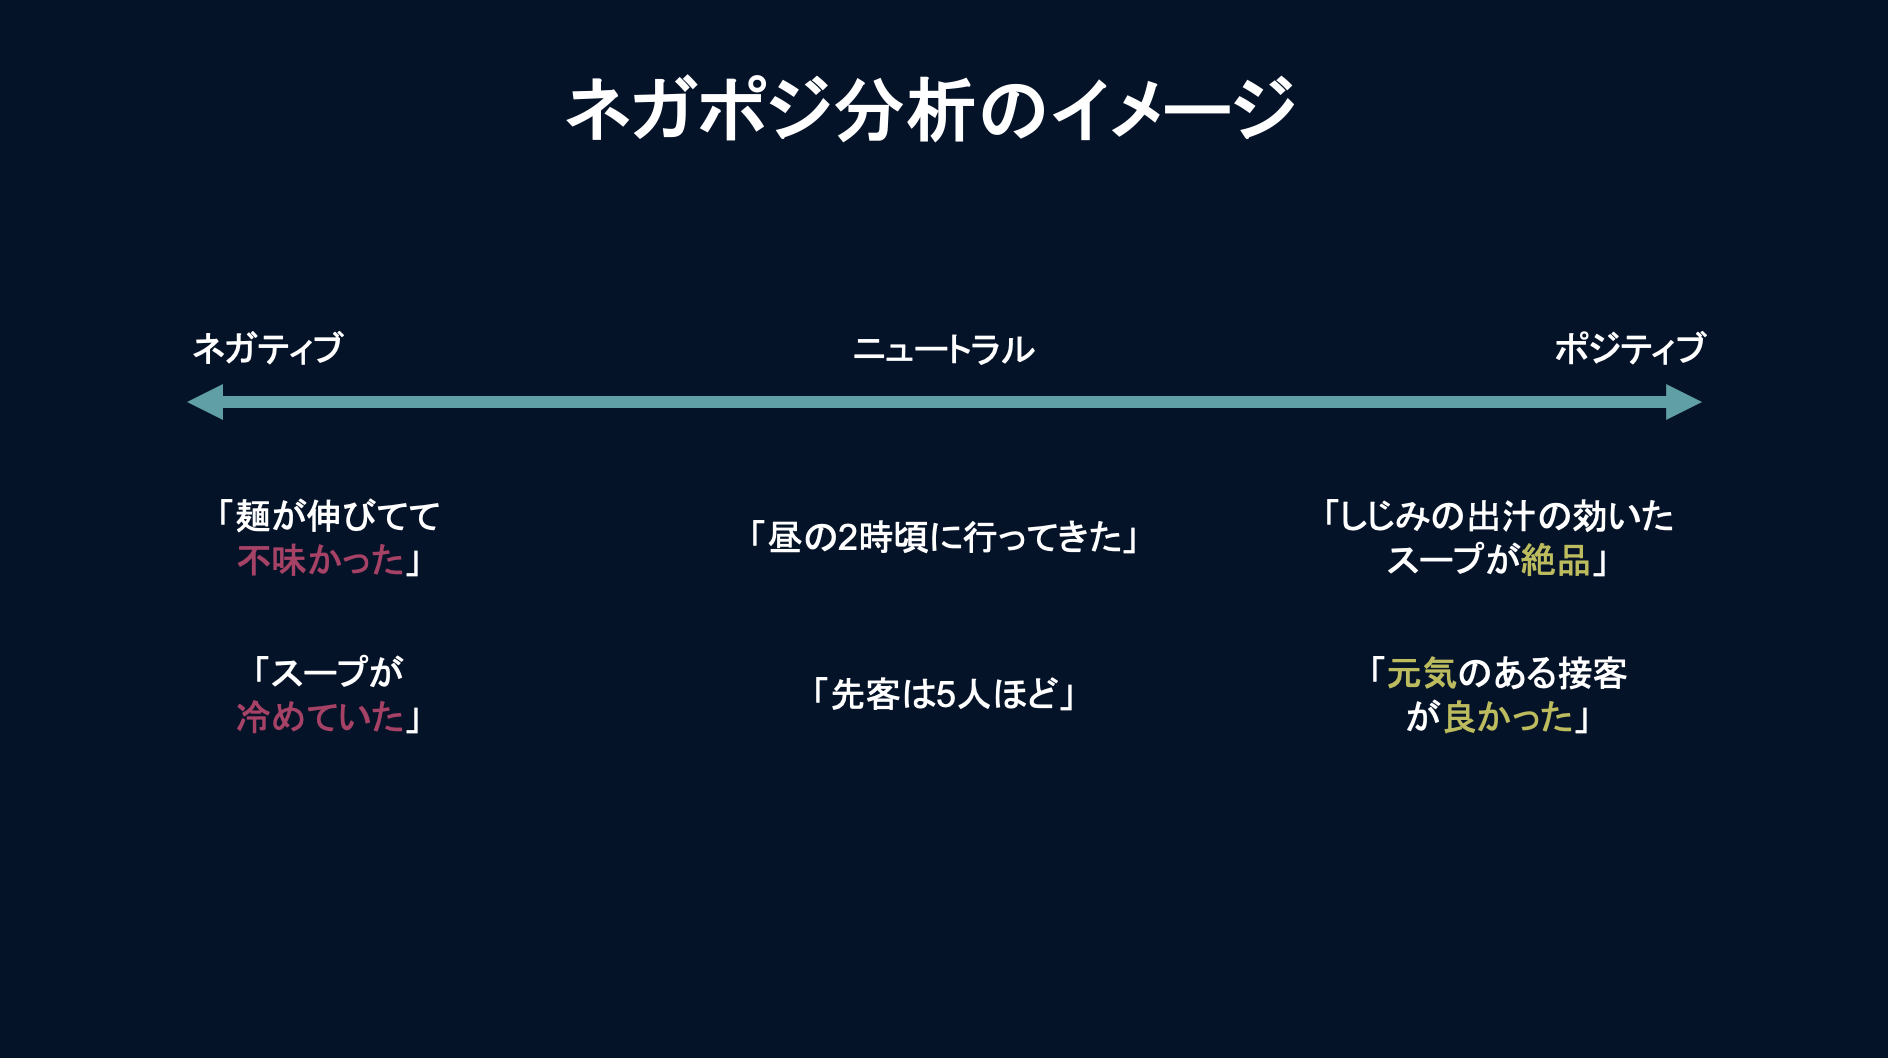

## <font color=#0e89b2>2.2 極性辞書を利用したネガポジ分析の仕組み</font>

### <font color=#0e89b2>a. 極性辞書とは</font>

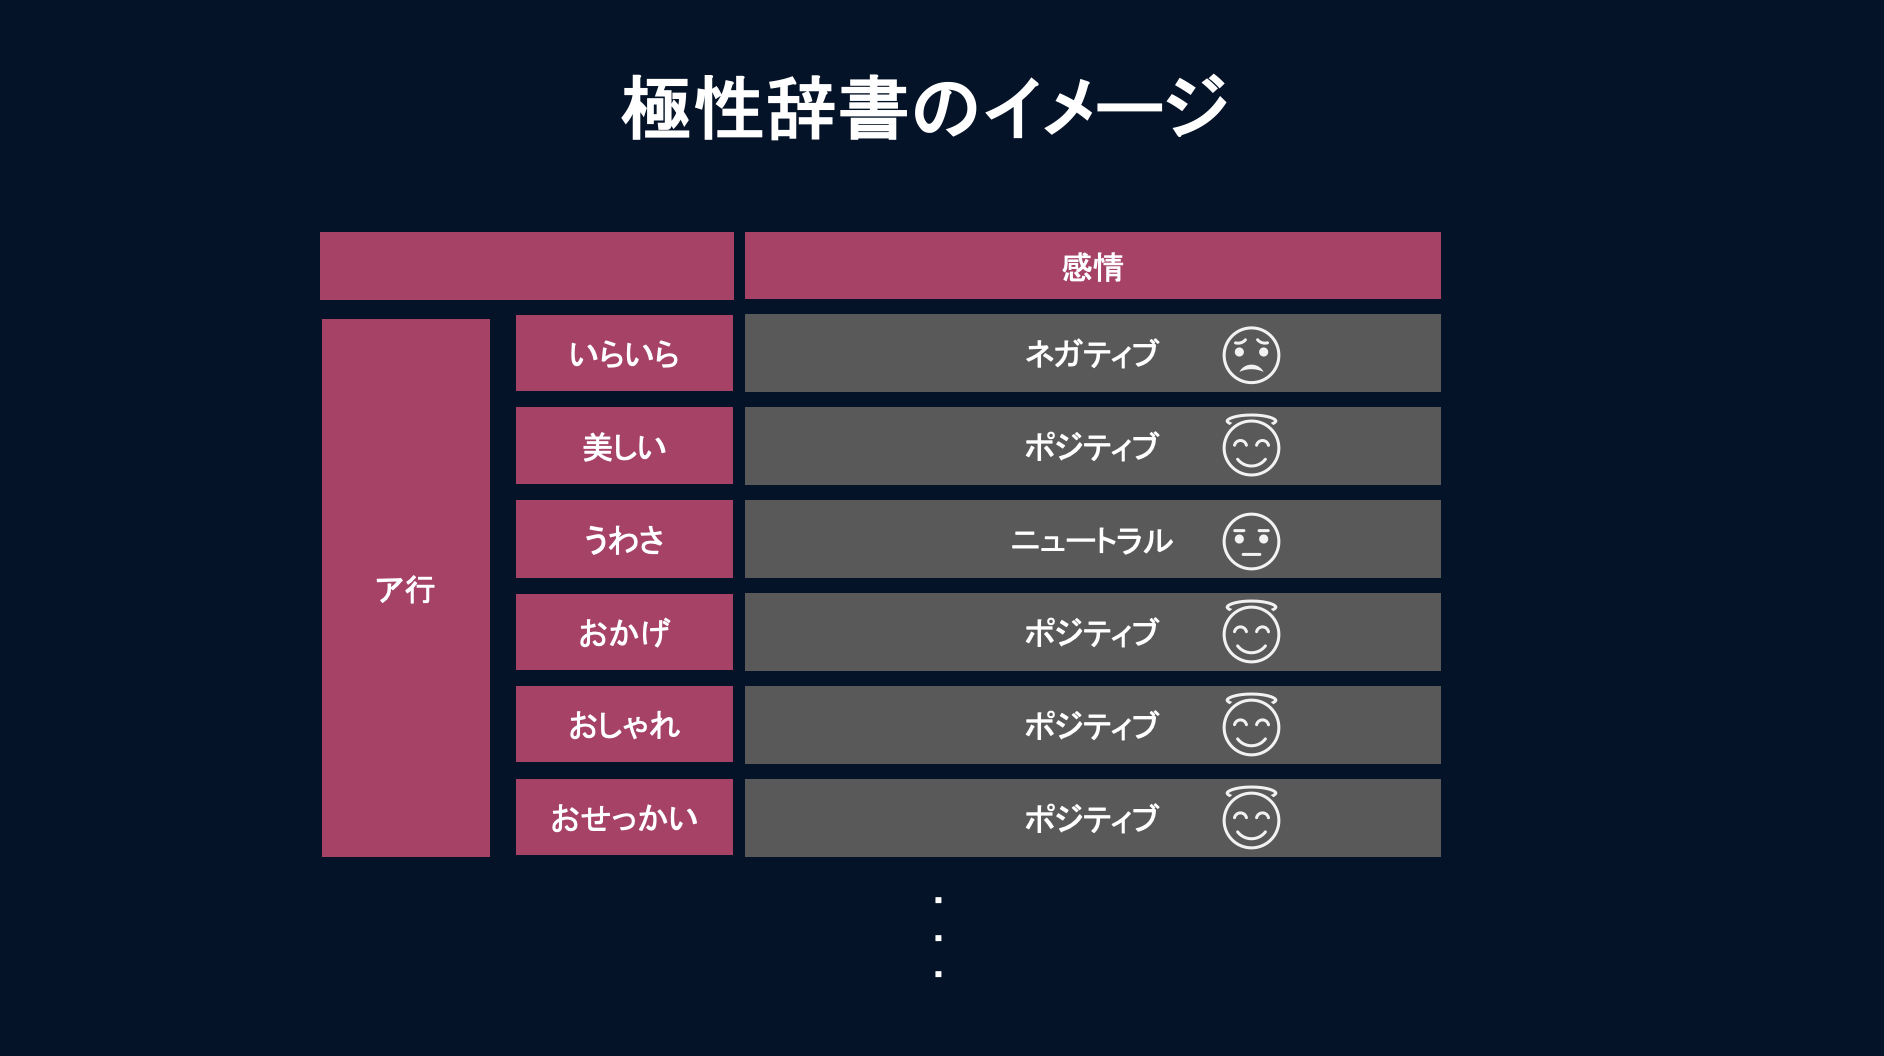

極性辞書とは、単語に「ポジティブ」「ネガティブ」といった感情の極性情報を付与した辞書のことです。<br>
<br>
日本語の極性辞書としては、以下の2つが有名です。
* 『日本語評価極性辞書』
 * 東北大の乾・岡崎研究室が公開
 * https://www.cl.ecei.tohoku.ac.jp/Open_Resources-Japanese_Sentiment_Polarity_Dictionary.html
* 『単語感情極性対応表』
 * 東工大の高村教授が公開
 * http://www.lr.pi.titech.ac.jp/~takamura/pndic_ja.html

 <br>

前者は商用利用も可能なので、今回は前者を使っていきます。<br>

>  著作者: 東北大学 乾・岡崎研究室 / Author(s): Inui-Okazaki Laboratory, Tohoku University<br>
東山昌彦, 乾健太郎, 松本裕治, 述語の選択選好性に着目した名詞評価極性の獲得, 言語処理学会第14回年次大会論文集, pp.584-587, 2008. / Masahiko Higashiyama, Kentaro Inui, Yuji Matsumoto. Learning Sentiment of Nouns from Selectional Preferences of Verbs and Adjectives, Proceedings of the 14th Annual Meeting of the Association for Natural Language Processing, pp.584-587, 2008.





### <font color=#0e89b2>b. 分析の仕組み</font>

## <font color=#0e89b2>2.3 極性辞書を利用したネガポジ分析の実装</font>

以下のような簡単な文章のネガポジを判定するモデルを実装してみましょう。
* 「今日は晴天で散歩日和だね」：ポジティブ

### <font color=#0e89b2>a. 極性辞書のダウンロード</font>

まずは東北大学の乾・岡崎研究室のHPから、極性辞書をダウンロードしていきます。<br>
<br>
ちなみに当研究室のHPでは、名詞編と用言編の2つの辞書が公開されていますが、<br>
今回は名詞編のみを利用します。

In [ ]:
!curl https://www.cl.ecei.tohoku.ac.jp/resources/sent_lex/pn.csv.m3.120408.trim > nouns_positive_negative.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  676k  100  676k    0     0   600k      0  0:00:01  0:00:01 --:--:--  600k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  177k  100  177k    0     0   235k      0 --:--:-- --:--:-- --:--:--  235k


ダウンロードしたファイルを、辞書形式で読み込んでみましょう。

In [ ]:
filename = '/content/nouns_positive_negative.csv'
with codecs.open(filename,'r','utf-8','ignore') as f:
    lines = f.readlines()
    dic = { x.split('\t')[0]:x.split('\t')[1] for x in lines }

In [ ]:
dic

4

無事極性辞書が読み込めています。<br>
以下のようなフラグが付いています。
* ポジティブな単語は"p"
* ネガティブな単語は"n"
* ニュートラルな単語は"e"

### <font color=#0e89b2>b. 評価したい文章の形態素解析</font>

次に評価したい文章を形態素解析して、名詞だけ抽出します。<br>
（極性辞書に動詞や形容詞なども含まれている場合は、もちろんここで動詞や形容詞も抽出します）

In [ ]:
text = "今日は晴天で散歩日和だね。駅前でケーキでも買って帰る？こないだの昇進のお祝いしようよ"

In [ ]:
#####写経#####
#ライブラリのインポート
from janome.tokenizer import Tokenizer

#辞書を読み込み、解析プログラムを起動状態にする
t = Tokenizer()
t

In [ ]:
#####写経#####
#分かち書き
tokens = t.tokenize(text)
words = []

for line in tokens:
    tkn = re.split('\t|,', str(line))
    # 名詞、形容詞、動詞で判定
    if tkn[1] in ['名詞'] :
        words.append(tkn[0])

In [ ]:
#####写経#####
words

['今日', '晴天', '散歩', '日和', '駅前', 'ケーキ', 'こないだ', '昇進', 'お祝い']

無事名詞のみ抽出できました。

### <font color=#0e89b2>c. ネガポジ判定</font>

上で抽出した名詞を極性辞書と照らし合わせて、ネガポジ判定をしていきます。<br>
やることはシンプルで、ポジティブな単語とネガティブな単語をそれぞれカウントしていくだけです。

In [ ]:
#####写経#####
#ポジティブな単語数とネガティブな単語数の計算
positive = 0
negative = 0
neutral = 0
error = 0

for word in words:
    res = dic.get(word,'-')
    if res == 'p':
        positive += 1
        print(word, "：ポジティブ")
    elif res == 'n':
        negative += 1
        print(word, "：ネガティブ")
    elif res == 'e':
        neutral += 1
    else:
        error += 1

晴天 ：ポジティブ
散歩 ：ポジティブ
昇進 ：ポジティブ


「晴天」などの単語がポジティブと判定されています。<br>
しかし、「お祝い」という明らかにポジティブな単語が、ポジティブと判定されていません。<br>
これは極性辞書に「お祝い」という単語が登録されていないためです。<br>
このように、極性辞書も万能ではないことには留意しておきましょう。<br>
<br>
最後に、文章のポジティブ率とネガティブ率を計算してみましょう。<br>
ここでの定義は以下とします。
* ポジティブ率：ポジティブな単語数/（ポジティブな単語数＋ネガティブな単語数）
* ネガティブ率：ネガティブな単語数/（ポジティブな単語数＋ネガティブな単語数）

In [ ]:
#####写経#####
#ポジティブ率とネガティブ率の計算
positive_rate = positive/(positive+negative)
negative_rate = negative/(positive+negative)
print("ポジティブ率：{}%".format(positive_rate*100))
print("ネガティブ率：{}%".format(negative_rate*100))

ポジティブ率：100.0%
ネガティブ率：0.0%


以上で、簡単なネガポジ分析のモデルを、ルールベースで実装出来ました。<br>
<br>
例えば以下のような改良を加えれば、さらに精度の高いモデルを作ることも可能です。
* 極性辞書に他の名詞を追加する
* 極性辞書に動詞、形容詞、形容動詞も追加する
* （動詞、形容詞、形容動詞を追加した場合）活用形にも対応する
* 否定表現に対応する（該当単語の次に否定表現が続いていたら、ポジネガをひっくり返して判定する）

# <font color=#0e89b2>3. 総合問題１：『注文の多い料理店』の感情変化の時系列グラフ化</font>

ここまで学んだルールベースでのネガポジ分析を用いて、<br>
宮沢賢治の有名な童話『注文の多い料理店』の主人公の感情変化を可視化してみましょう。<br>
<br>
まずはあらすじを簡単に確認しておきましょう。<br>
<br>
◆あらすじ
* 2人の紳士が、ぴかぴかの鉄砲と白熊のような犬2匹を携えて、山奥に猟をしにきました。しかし全く成果は挙がらない上に山の雰囲気は不気味で、2匹の犬もめまいを起こして死んでしまいます。彼らは山から引き上げることにしますが、道に迷ってしまいました。
* ふと後ろを見ると、立派な洋館があります。そして玄関には、「西洋料理店 山猫軒」という札が出ています。「どなたもどうかお入りください。決してご遠慮はありません」という案内書きに安心し、彼らは中に入ります。
* 中には扉があり、「当軒は注文の多い料理店ですからどうかそこはご承知ください」と書かれている。2人はこの文言を「繁盛して注文が込み合っている」という意味だと捉え、奥に進みます。
* さらに扉は続き、「髪をといて、履物の泥を落としてください」「帽子と外套と靴を脱いでください」「壺の中のクリームを顔や手足に塗ってください」など、2人への「注文」は続きますが、彼らは「よほど偉い人が来ているのだろう」と好意的に捉えてさらに進みます。
* さらに進んだ先に、「からだ中に、壺の中の塩をたくさんよくもみ込んでください」と書かれています。ここで初めて2人は、この店は「客に西洋料理を食べさせる店」ではなく、「客を西洋料理にして食べる店」だと気づき、震え上がります。
* 2人は逃げようとしますが、扉はびくともしません。ぐしゃぐしゃに泣いているところへ、死んだと思っていた犬が2匹飛び込んで来ます。2匹は扉の奥の暗闇に飛びつくと、暗闇の中で「にゃあお、くゎあ、ごろごろ」という鳴き声がして、山猫軒の建物は霧のように消え去りました。

<br>

◆問題<br>
『注文の多い料理店』の主人公の感情変化を、「ポジティブ率」と「ネガティブ率」の2本の折れ線グラフで可視化してください。
* ポジティブ率とネガティブ率の定義は下記とします。
 * ポジティブ率：ポジティブな単語数 / (ポジティブな単語数+ネガティブな単語数+ニュートラルな単語数+いずれでもない単語数）
 * ネガティブ率：ネガティブな単語数 / (ポジティブな単語数+ネガティブな単語数+ニュートラルな単語数+いずれでもない単語数）
 * ※極性辞書に載っていない単語が、「いずれでもない単語」に該当します。
* ポジティブ率とネガティブ率は、10行ごとに計算してください。

<br>

完成イメージはこちらです。


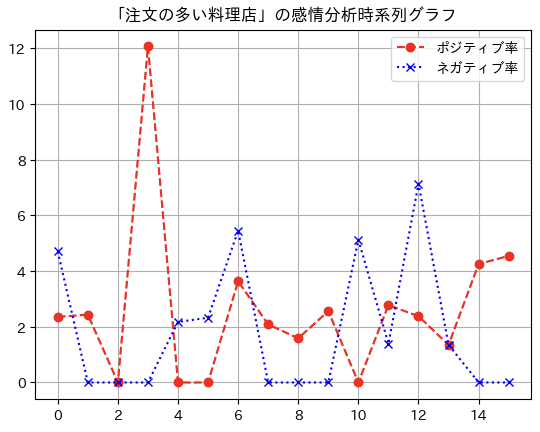

なお、10行ごとの塊をブロックと呼ぶとすると、各ブロックのストーリーの内容は下記のようになります。
* ブロック0：狩猟の成果が出ない上に、山は不気味で犬も死ぬ
* ブロック2〜3：洋館を見つける
* ブロック4〜10：色々な注文に多少の疑問を抱きつつも、好意的に解釈して先に進む
* ブロック11〜12：異変に気づき、泣いて逃げようとする
* ブロック13〜15：犬が助けに来て無事助かる

ストーリー展開を上手く捉えた感情分析が出来るでしょうか。

テキストデータはこちらを使用してください。

In [ ]:
#再実行用ファイル削除
! rm 43754_ruby_17594.zip
! rm chumonno_oi_ryoriten.txt
! rm miyazawa_chumon.txt

#青空文庫の「注文の多い料理店」のURLを指定し、ダウンロード
! wget https://www.aozora.gr.jp/cards/000081/files/43754_ruby_17594.zip

#zipファイルを解凍する
! unzip 43754_ruby_17594.zip

#テキストファイルを開き、その内容を変数dataに読み込む
f = open('/content/chumonno_oi_ryoriten.txt', 'r', encoding='SJIS')
data = f.read()
f.close()

#改行記号を削除する
#re.sub("置換前の文字列", "置換後の文字列", 対象の変数名)
data = re.sub("\u3000", "", data)
#data = re.sub("\n", "", data)

#《 》で囲まれたルビを削除する
data = re.sub("《[^》]+》", "", data)

#［＃］ で囲まれたルビを削除する
data = re.sub(r'［＃(.+)］', "", data)

#文頭の説明を削除する
data = data[164:]
#data = re.sub("注文の多い料理店\n宮沢賢治\n\n\n【テキスト中に現れる記号について】\n\n《》：ルビ\n（例）紳士\n\n｜：ルビの付く文字列の始まりを特定する記号\n（例）二｜疋\n\n［＃］：入力者注主に外字の説明や、傍点の位置の指定\n（例）\n\n\n", "", data)
data = re.sub("------------------------------------------------------\n\n", "", data)

#文末の説明を削除する　data[(len(data)-251):]で部末から表示
data = re.sub("\n\n\n\n底本：「注文の多い料理店」新潮文庫、新潮社\n1990（平成2）年5月25日発行\n1997（平成9）年5月10日17刷\n初出：「イーハトヴ童話注文の多い料理店」盛岡市杜陵出版部・東京光原社\n1924（大正13）年12月1日\n入力：土屋隆\n校正：noriko saito\n2005年1月26日作成\n青空文庫作成ファイル：\nこのファイルは、インターネットの図書館、青空文庫（http://www.aozora.gr.jp/）で作られました。入力、校正、制作にあたったのは、ボランティアの皆さんです。\n", "", data)

#2つの改行は１つにする
data = data.replace('\n\n', '\n')


#文字列をファイルに出力
f = open('miyazawa_chumon.txt', 'w')
f.write(data)
f.close()

#表示
data

rm: cannot remove '43754_ruby_17594.zip': No such file or directory
rm: cannot remove 'chumonno_oi_ryoriten.txt': No such file or directory
rm: cannot remove 'miyazawa_chumon.txt': No such file or directory
--2024-02-14 09:52:54--  https://www.aozora.gr.jp/cards/000081/files/43754_ruby_17594.zip
Resolving www.aozora.gr.jp (www.aozora.gr.jp)... 59.106.13.115
Connecting to www.aozora.gr.jp (www.aozora.gr.jp)|59.106.13.115|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6290 (6.1K) [application/zip]
Saving to: ‘43754_ruby_17594.zip’

43754_ruby_17594.zi 100%[===================>]   6.14K  --.-KB/s    in 0s      

2024-02-14 09:52:54 (1.32 GB/s) - ‘43754_ruby_17594.zip’ saved [6290/6290]

Archive:  43754_ruby_17594.zip
  inflating: chumonno_oi_ryoriten.txt  


'二人の若い紳士が、すっかりイギリスの兵隊のかたちをして、ぴかぴかする鉄砲をかついで、白熊のような犬を二｜疋つれて、だいぶ山奥の、木の葉のかさかさしたとこを、こんなことを云いながら、あるいておりました。\n「ぜんたい、ここらの山は怪しからんね。鳥も獣も一疋も居やがらん。なんでも構わないから、早くタンタアーンと、やって見たいもんだなあ。」\n「鹿の黄いろな横っ腹なんぞに、二三発お見舞もうしたら、ずいぶん痛快だろうねえ。くるくるまわって、それからどたっと倒れるだろうねえ。」\nそれはだいぶの山奥でした。案内してきた専門の鉄砲打ちも、ちょっとまごついて、どこかへ行ってしまったくらいの山奥でした。\nそれに、あんまり山が物凄いので、その白熊のような犬が、二疋いっしょにめまいを起こして、しばらく吠って、それから泡を吐いて死んでしまいました。\n「じつにぼくは、二千四百円の損害だ」と一人の紳士が、その犬の眼ぶたを、ちょっとかえしてみて言いました。\n「ぼくは二千八百円の損害だ。」と、もひとりが、くやしそうに、あたまをまげて言いました。\nはじめの紳士は、すこし顔いろを悪くして、じっと、もひとりの紳士の、顔つきを見ながら云いました。\n「ぼくはもう戻ろうとおもう。」\n「さあ、ぼくもちょうど寒くはなったし腹は空いてきたし戻ろうとおもう。」\n「そいじゃ、これで切りあげよう。なあに戻りに、昨日の宿屋で、山鳥を拾円も買って帰ればいい。」\n「兎もでていたねえ。そうすれば結局おんなじこった。では帰ろうじゃないか」\nところがどうも困ったことは、どっちへ行けば戻れるのか、いっこうに見当がつかなくなっていました。\n風がどうと吹いてきて、草はざわざわ、木の葉はかさかさ、木はごとんごとんと鳴りました。\n「どうも腹が空いた。さっきから横っ腹が痛くてたまらないんだ。」\n「ぼくもそうだ。もうあんまりあるきたくないな。」\n「あるきたくないよ。ああ困ったなあ、何かたべたいなあ。」\n「喰べたいもんだなあ」\n二人の紳士は、ざわざわ鳴るすすきの中で、こんなことを云いました。\nその時ふとうしろを見ますと、立派な一軒の西洋造りの家がありました。\nそして玄関には\nRESTAURANT\n西洋料理店\nWILDCAT HOUSE\n山猫軒\nという札がでていました。\n「君、ちょうどいい。ここはこれ

解答

In [ ]:
#文章をわかち書きするための関数
def wakati(text):
  tokens = t.tokenize(text)
  words = []

  for line in tokens:
      tkn = re.split('\t|,', str(line))
      # 名詞、形容詞、動詞で判定
      if tkn[1] in ['名詞'] :
          words.append(tkn[0])
  return words

In [ ]:
#ポジティブな単語数とネガティブな単語数を計算するための関数
def posinega_analyze(words):
  positive = 0
  negative = 0
  neutral = 0
  error = 0

  for word in words:
      res = dic.get(word,'-')
      if res == 'p':
          positive += 1
      elif res == 'n':
          negative += 1
      elif res == 'e':
          neutral += 1
      else:
          error += 1
  return positive, negative, neutral, error

In [ ]:
#改行で１行ずつに分割
lines = data.split("\n")
lines[:3]

['二人の若い紳士が、すっかりイギリスの兵隊のかたちをして、ぴかぴかする鉄砲をかついで、白熊のような犬を二｜疋つれて、だいぶ山奥の、木の葉のかさかさしたとこを、こんなことを云いながら、あるいておりました。',
 '「ぜんたい、ここらの山は怪しからんね。鳥も獣も一疋も居やがらん。なんでも構わないから、早くタンタアーンと、やって見たいもんだなあ。」',
 '「鹿の黄いろな横っ腹なんぞに、二三発お見舞もうしたら、ずいぶん痛快だろうねえ。くるくるまわって、それからどたっと倒れるだろうねえ。」']

In [ ]:
#1行ずつ読んで分析する
for line in lines:
  print(line)         # 元の文書を表示
  words = wakati(line)
  result = posinega_analyze(words)  # 感情分析の実行
  print("(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数)" + " " + "=" + " " + str(result))          # 結果の表示
  print("-----------")

二人の若い紳士が、すっかりイギリスの兵隊のかたちをして、ぴかぴかする鉄砲をかついで、白熊のような犬を二｜疋つれて、だいぶ山奥の、木の葉のかさかさしたとこを、こんなことを云いながら、あるいておりました。
(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数) = (0, 0, 2, 14)
-----------
「ぜんたい、ここらの山は怪しからんね。鳥も獣も一疋も居やがらん。なんでも構わないから、早くタンタアーンと、やって見たいもんだなあ。」
獣 ：ネガティブ
(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数) = (0, 1, 1, 9)
-----------
「鹿の黄いろな横っ腹なんぞに、二三発お見舞もうしたら、ずいぶん痛快だろうねえ。くるくるまわって、それからどたっと倒れるだろうねえ。」
痛快 ：ポジティブ
(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数) = (1, 0, 0, 7)
-----------
それはだいぶの山奥でした。案内してきた専門の鉄砲打ちも、ちょっとまごついて、どこかへ行ってしまったくらいの山奥でした。
専門 ：ポジティブ
(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数) = (1, 0, 1, 6)
-----------
それに、あんまり山が物凄いので、その白熊のような犬が、二疋いっしょにめまいを起こして、しばらく吠って、それから泡を吐いて死んでしまいました。
めまい ：ネガティブ
(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数) = (0, 1, 1, 8)
-----------
「じつにぼくは、二千四百円の損害だ」と一人の紳士が、その犬の眼ぶたを、ちょっとかえしてみて言いました。
損害 ：ネガティブ
(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数) = (0, 1, 1, 11)
-----------
「ぼくは二千八百円の損害だ。」と、もひとりが、くやしそうに、あたまをまげて言いました。
損害 ：ネガティブ
(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数) = (0, 1, 0, 9)
-----------
はじめの紳士は、すこし顔いろを悪くして、じっと、もひとりの紳士の、顔つきを見ながら云いました。
(ポジティブ数,ネガティブ数,ニュートラル数,判定不可数)

In [ ]:
positive_num = []
negative_num = []
neutral_num = []
error_num = []

#1行ずつ読んで分析する
for line in lines:
  words = wakati(line)
  result = posinega_analyze(words)  # 感情分析の実行
  positive_num.append(result[0])
  negative_num.append(result[1])
  neutral_num.append(result[2])
  error_num.append(result[3])

In [ ]:
df = pd.DataFrame([positive_num, negative_num, neutral_num, error_num], index=["ポジティブ", "ネガティブ", "ニュートラル", "エラー"]).T

In [ ]:
df_block = df.groupby(df.index // 10).sum()
df_block["ポジティブ率"] = (df_block["ポジティブ"] / (df_block["ポジティブ"] + df_block["ネガティブ"] + df_block["ニュートラル"] + df_block["エラー"])) * 100
df_block["ネガティブ率"] = df_block["ネガティブ"] / ((df_block["ポジティブ"] + df_block["ネガティブ"] + df_block["ニュートラル"] + df_block["エラー"])) * 100

In [ ]:
df_block

,ポジティブ,ネガティブ,ニュートラル,エラー,ポジティブ率,ネガティブ率
0,2,4,6,73,2.352941,4.705882
1,1,0,2,38,2.439024,0.000000
2,0,0,2,23,0.000000,0.000000
3,7,0,7,44,12.068966,0.000000
4,0,1,12,33,0.000000,2.173913
5,0,1,6,36,0.000000,2.325581
6,2,3,13,37,3.636364,5.454545
7,1,0,12,35,2.083333,0.000000
8,1,0,8,54,1.587302,0.000000
9,1,0,5,33,2.564103,0.000000


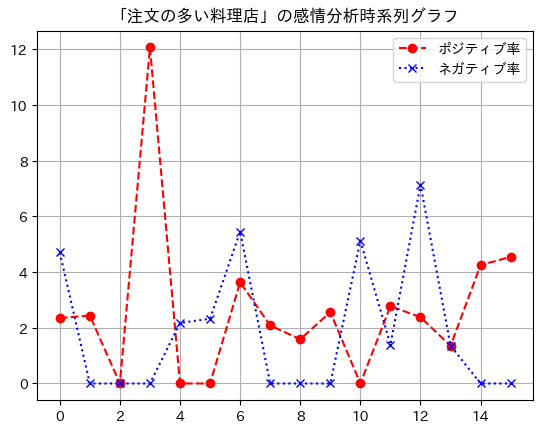

In [ ]:
#リスト内包表記で、 xに0から153の数字を入力
x = [ i for i in range(len(df_block)) ]

#ポジティブ率のグラフ
plt.plot(x, df_block["ポジティブ率"], marker="o", color = "red",  linestyle = "--", label="ポジティブ率")

#ネガティブ率のグラフ
plt.plot(x, df_block["ネガティブ率"], marker="x", color = "blue", linestyle = ":" , label="ネガティブ率")

#グラフタイトル
plt.title('「注文の多い料理店」の感情分析時系列グラフ')

#表示
plt.legend()
plt.grid(True)
plt.show()

なお、ブロックごとの主なストーリーの内容はこちらの通りでした。
* ブロック0：狩猟の成果が出ない上に、山は不気味で犬も死ぬ
* ブロック2〜3：洋館を見つける
* ブロック4〜10：色々な注文に多少の疑問を抱きつつも、好意的に解釈して先に進む
* ブロック11〜12：異変に気づき、泣いて逃げようとする
* ブロック13〜15：犬が助けに来て無事助かる

<br>

今回実装したのは、単語（しかも名詞のみ）ごとにポジネガ判定してその比率を数えるという、かなりシンプルなモデルでした。<br>
それでも、『注文の多い料理店』のストーリー展開に即した感情変化を上手く捉えられていることが分かります。